In [1]:
# # test 
# import ngsolve as ngs
# from netgen.meshing import Mesh as NetMesh
# from netgen.geom2d import unit_square

# mesh = ngs.Mesh(unit_square.GenerateMesh(maxh=0.2))

# V = H1(mesh, order=1)
# u = V.TrialFunction()
# v = V.TestFunction()

# print("NGSolve")

In [2]:
# create the stationary FOM using ngsolve
# here define mesh, FE-space, operators

# here we tell ngsolve what to do when pyMOR calls it

import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw
from ngsolve.meshes import Make1DMesh


alpha = 1.0
beta = Parameter(3.25)  # solve for different beta later
nu = 0.01
h = 50                  # (compare 50 and 100 later)
order = 2               # quadratic Lagrange basis functions

mesh = Make1DMesh(h)   # mesh on (0,1) into h pieces

# V_h = V_u * V_v 
V_h = H1(mesh, order=order, dirichlet="right") * H1(mesh, order=order, dirichlet="right")

u, v = V_h.TrialFunction()    # represent unknowns 
phi, psi = V_h.TestFunction() # test functions ("for u and v")


# This holds the values where the nonlinear operator is evaluated
w_h = GridFunction(V_h)          # w_h element in V_h with zeros
u_part, v_part = w_h.components  # seperate u and v part in w_h 

# generate mass Matrix m 
m = BilinearForm(V_h)   # m: V_h x V_h to R
m += (u * phi + v * psi) * dx   # u * phi fills the upper-left block (u part)
                                # v * psi fills the lower-right block (v part)
m.Assemble()

# generate stiffness matrix a
a = BilinearForm(V_h)   # a: V_h x V_h to R
a += (nu * grad(u) * grad(phi) + nu * grad(v) * grad(psi)) * dx
a.Assemble()

# for the non-lin part we use Newtons method $$F(u + \delta u) \approx F(u) + F'(u)* \delta u$$
# for Newton we need the residual and the Jacobian

# 0 != a*v_h - f(v) (= F(u))
def spatial_residual(vec, beta):    # res(v) = a*v - f(v)
 
    beta_val = beta.item() if hasattr(beta, 'item') else float(beta)    #(both, for manual case and intern solver)
        
    w_h.vec.data = vec
   # u_part, v_part = w_h.components[0], w_h.components[1]
    u_part, v_part = list(w_h.components)
    y = alpha + u_part        # lifting part as in the paper
    z = (beta_val/alpha) + v_part
    
    
    # define the residual
    res = LinearForm(V_h)   # res: V_h to R
    
    # Linear Diffusion part: A * w_h
    #res += (nu * grad(u_part) * grad(phi) + nu * grad(v_part) * grad(psi)) * dx    # add diffusion part
    res.vec.data = a.mat * w_h.vec    # matrix-vector-mult
    
    # f_u = y^2*z - (beta+1)*y + alpha
    # f_v = beta*y - y^2*z
    res += -(y**2 * z - (beta_val + 1) * y + alpha) * phi * dx     # non-lin part
    res += -(beta_val * y - y**2 * z) * psi * dx
    
    res.Assemble()

    final_vec = res.vec + a.mat * w_h.vec

    return final_vec  # BaseVector as input, BaseVector as output

# J_ij = \frac{\partial F_i}{u_j}
def jacobian(vec, beta):
 
    beta_val = beta.item() if hasattr(beta, 'item') else float(beta)
    
    w_h.vec.data = vec
    u_part, v_part = list(w_h.components)
   # u_part, v_part = w_h.components[0], w_h.components[1]
    
    y = alpha + u_part
    z = (beta_val/alpha) + v_part
    
    jac = BilinearForm(V_h)
    
    jac += (nu * grad(u) * grad(phi) + nu * grad(v) * grad(psi)) * dx   # linear part
    
    # d/du (y^2 z - (beta+1)y + alpha) = 2yz - (beta+1)
    # d/dv (y^2 z - (beta+1)y + alpha) = y^2
    jac += -( (2*y*z - (beta_val+1))*u + (y**2)*v ) * phi * dx   
    # d/du (beta*y - y^2 z) = beta - 2yz
    # d/dv (beta*y - y^2 z) = -y^2
    jac += -( (beta_val - 2*y*z)*u - (y**2)*v ) * psi * dx
    
    jac.Assemble()
    return jac.mat   # BaseVector as input, SparseMatrix as output


In [3]:
# bind the linear parts

from pymor.bindings.ngsolve import NGSolveMatrixOperator, NGSolveVectorSpace

# define the pyMOR VectorSpace from your NGSolve FE space
v_space = NGSolveVectorSpace(V_h)    # make it a pyMOR VectorSpace

m_op = NGSolveMatrixOperator(m.mat, range=v_space, source=v_space)   # pyMOR operator that takes VectorArray as input
a_op = NGSolveMatrixOperator(a.mat, range=v_space, source=v_space)


In [4]:
# here create the Operator A (we can plug into InstationaryModel)
# create a new Operator that inherits from Operator (pyMOR object)

from pymor.operators.interface import Operator

class BrusselatorOperator(Operator):
    def __init__(self, V_h, a_form, residual_func, jacobian_func):

        super().__init__()  # inherit from Operator

        self.linear = False
        
        self.V_h = V_h
        self.source = v_space
        self.range = v_space
        
        self.a_form = a_form
        self.residual_func = residual_func
        self.jacobian_func = jacobian_func

        self.parameters_own = {'beta': 1} # this is the parameter

    def apply(self, U, mu=None):

        gfu_impl = U.vectors[0].real_part.impl   # get the Gridfunction
    
        vec_ng = gfu_impl.vec    # get the BaseVector
        current_beta = mu['beta']   # update beta
    
        res_vec = self.residual_func(vec_ng, current_beta)  # compute in ngsolve, return basevector
    
        res_gf = GridFunction(self.V_h)  # wrap into new gridfunction
        res_gf.vec.data = res_vec
    
        return self.range.make_array([res_gf])      # make VectorArray

        
    def jacobian(self, U, mu=None):
        
        gfu_impl = U.vectors[0].real_part.impl
        vec_ng = gfu_impl.vec
        
        # compute jacobian in ngsolve
        current_beta = mu['beta']
        mat_ng = self.jacobian_func(vec_ng, current_beta)
        
      
        return NGSolveMatrixOperator(mat_ng, range=self.range, source=self.source)



In [5]:
# ingridients for the Model

# create the concrete operator we want
a_br = BrusselatorOperator(
    V_h=V_h, 
    a_form=a_op, 
    residual_func=spatial_residual, 
    jacobian_func=jacobian
)

# # initial data
# gfu0 = GridFunction(V_h)
# gfu0.components[0].Set(alpha)   # start at steady state
# gfu0.components[1].Set(beta/alpha)

# # for pyMOR
# u0_vec = v_space.make_array([gfu0])

# 1. NEW INITIAL CONDITION (The "Kick")
gfu0 = GridFunction(V_h)
# Add a tiny bit of sine wave to 'u' to break symmetry
gfu0.components[0].Set(0.1 * sin(3.14 * x)) 
u0_vec = v_space.make_array([gfu0])

In [6]:
# Test the Mass Matrix directly
try:
    test_apply = m_op.apply(u0_vec)
    print("Mass matrix apply works!")
except AttributeError as e:
    print(f"Mass matrix apply failed: {e}")

# Test your Operator directly
try:
    test_nonlinear = a_br.apply(u0_vec, mu={'beta': 1.0})
    print("Nonlinear operator apply works!")
except AttributeError as e:
    print(f"Nonlinear operator apply failed: {e}")

Mass matrix apply works!
Nonlinear operator apply works!


In [21]:
from pymor.models.basic import InstationaryModel
from pymor.algorithms.timestepping import ImplicitEulerTimeStepper

Brusselator_fom = InstationaryModel(
    T=7.0,
    initial_data=u0_vec,
    operator=a_br, # A
    mass=m_op,     # M
    rhs=None,     # f
    time_stepper=ImplicitEulerTimeStepper(nt=100)
)

# make initial cond an operator(beta)

In [22]:
U=Brusselator_fom.solve({'beta': 3.0})

Accordion(children=(HTML(value='', layout=Layout(height='16em', width='100%')),), titles=('Log Output',))

In [23]:
print(f"Number of snapshots: {len(U)}")
print(f"Size of each snapshot (DoFs): {U.dim}")

# Look at the first 5 norms to see the 'kick' start to move
print("First 5 time-step norms:", U.norm()[:5])

# Look at the last 5 norms to see if it's still growing
print("Last 5 time-step norms:", U.norm()[-5:])

Number of snapshots: 101
Size of each snapshot (DoFs): 202
First 5 time-step norms: [0.50013055 0.59196488 0.70827024 0.84344749 0.99350165]
Last 5 time-step norms: [7.9887735  7.60238637 7.10434842 6.47378339 5.71351328]


In [25]:
Brusselator_fom.visualize(U)

NotImplementedError: Model has no visualizer.

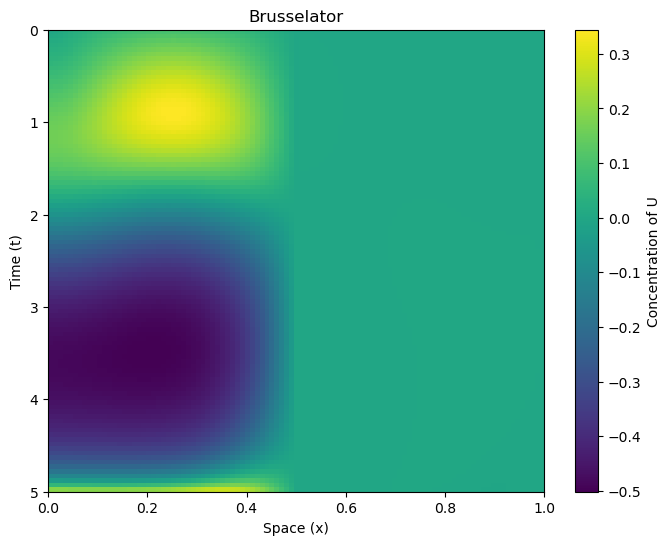

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Convert U to a 2D numpy array (Time x Space)
# We take only the first 101 columns (the 'u' chemical)
u_data = np.array([vec.to_numpy().flatten()[:101] for vec in U])

plt.figure(figsize=(8, 6))
plt.imshow(u_data, extent=[0, 1, 5, 0], aspect='auto', cmap='viridis')
plt.colorbar(label='Concentration of U')
plt.xlabel('Space (x)')
plt.ylabel('Time (t)')
plt.title('Brusselator')
plt.show()